## Exploratory Data Analysis on E-Commerce Dataset
 Objective:
The objective of this project is to perform Exploratory Data Analysis (EDA) on an E-Commerce dataset using Python libraries such as Pandas, Matplotlib, and Seaborn to identify patterns, trends, relationships, and useful business insights.

In [1]:
#Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Dataset
df = pd.read_csv("E-Commerce Dataset.csv", encoding='latin1')
df.head() #Read first 5 Rows

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
# Display dataset information such as columns, data types, and non-null values
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
# Generate statistical summary of numerical columns (mean, min, max, standard deviation)
df.describe() 

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
# Check for missing/null values in each column
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
# Removing rows where CustomerID is missing
df = df.dropna(subset=["CustomerID"])

In [7]:
# Country-wise Transaction Distribution
df["Country"].value_counts()

Country
United Kingdom          361878
Germany                   9495
France                    8491
EIRE                      7485
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               1877
Portugal                  1480
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
USA                        291
Israel                     250
Unspecified                244
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58
Lebanon                     45


## Visualization

## Histogram 
Majority products have lower prices.

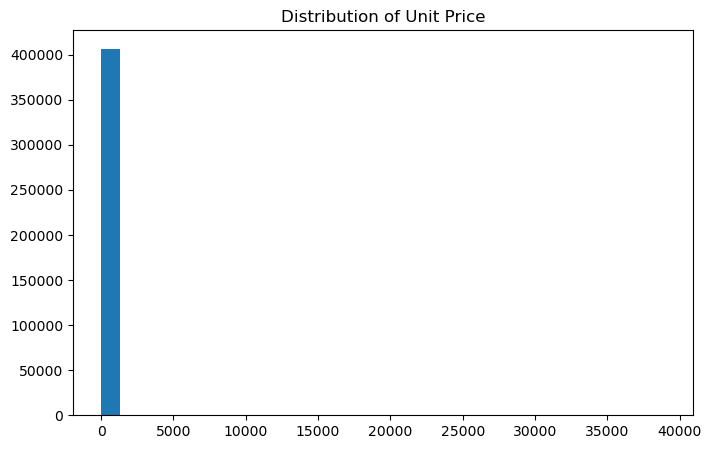

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["UnitPrice"], bins=30)
plt.title("Distribution of Unit Price")
plt.show()

## Box Plot
Some products have extreme high prices (outliers).

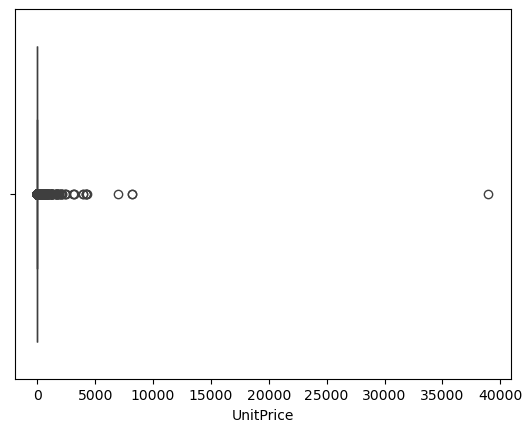

In [9]:
sns.boxplot(x=df["UnitPrice"])
plt.show()

 ## Creating Sales Column

In [10]:
df["Sales"] = df["Quantity"] * df["UnitPrice"]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


## Top 10 Countries by Sales

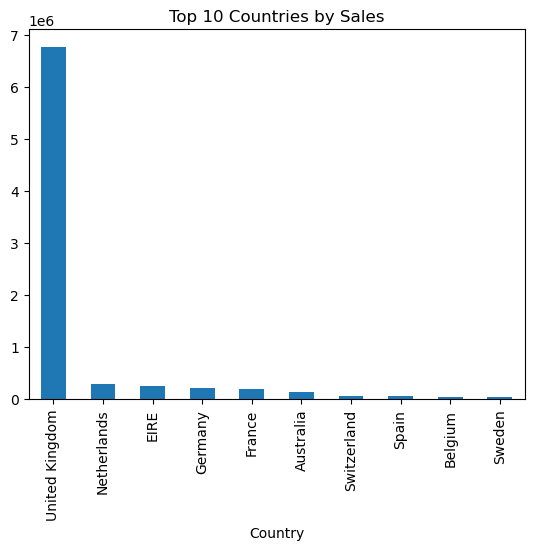

In [11]:
#This chart shows countries generating highest sales revenue.
top_country = df.groupby("Country")["Sales"].sum().sort_values(ascending=False).head(10)

top_country.plot(kind="bar")
plt.title("Top 10 Countries by Sales")
plt.show()

## Top 10 Products Sold

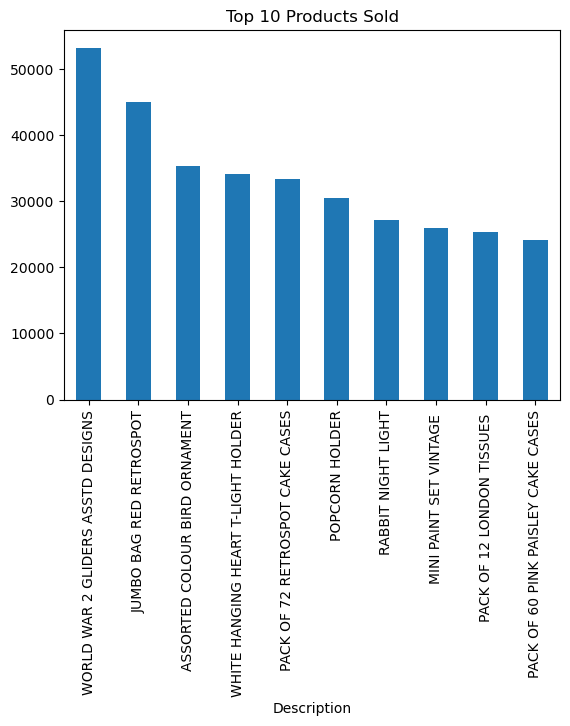

In [12]:
#This analysis identifies products sold in highest quantity.
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar")
plt.title("Top 10 Products Sold")
plt.show()

## Scatter Plot
Weak relationship between quantity and unit price.

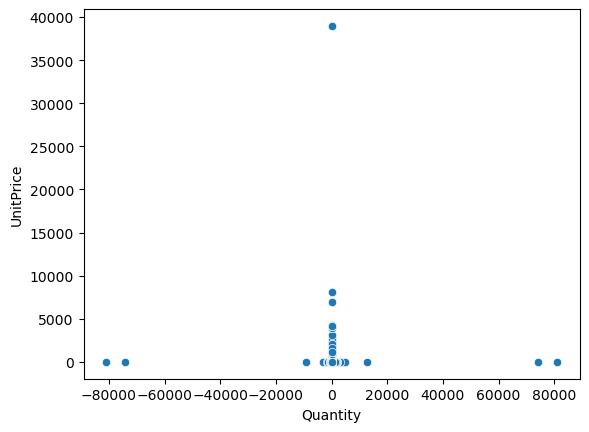

In [13]:
sns.scatterplot(x=df["Quantity"], y=df["UnitPrice"])
plt.show()

## HeatMap
Numerical features have weak correlation.

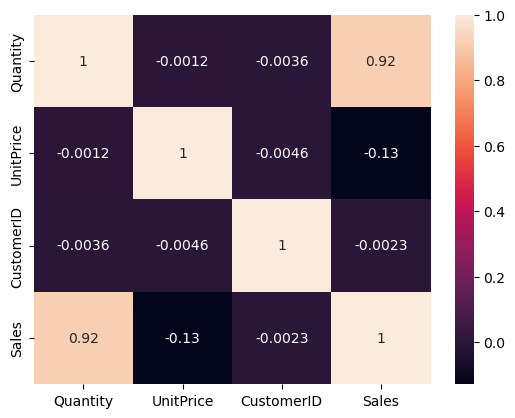

In [14]:
numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

## Pairplot
Pairplot helps visualize multiple feature relationships.

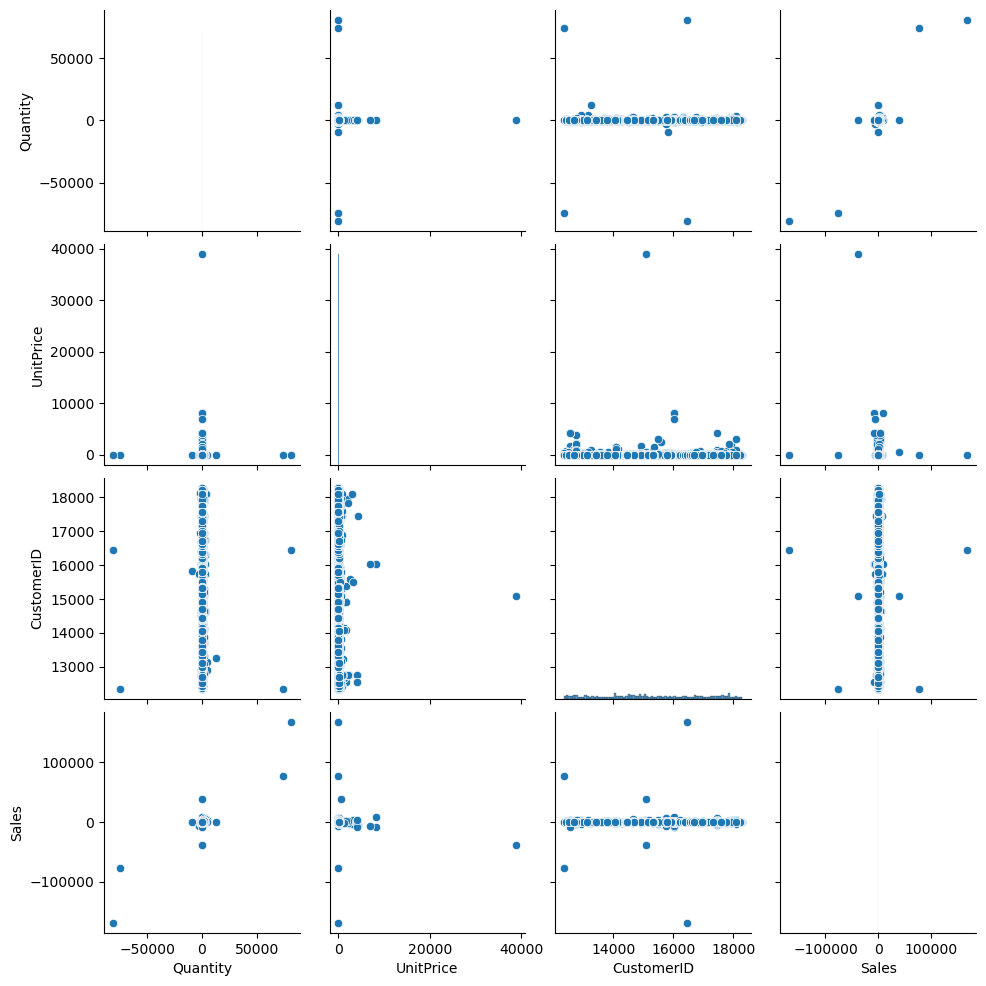

In [15]:
sns.pairplot(numeric_df)
plt.show()

## Trend Analysis
Some countries contribute more product sales.

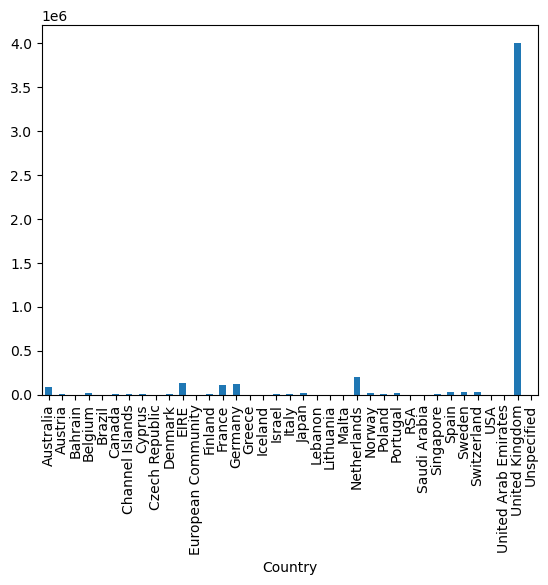

In [16]:
country_sales = df.groupby("Country")["Quantity"].sum()

country_sales.plot(kind="bar")
plt.show()

# Final Summary of Findings

1. Dataset contains missing values in CustomerID column.  
2. Most products have low unit prices.  
3. UnitPrice column contains outliers.  
4. Country distribution is uneven.  
5. Quantity and UnitPrice have weak correlation.  
6. Some countries contribute more sales volume.  

## Conclusion
This project demonstrates practical use of Python, Pandas, Matplotlib and EDA techniques for extracting business insights from real-world e-commerce transaction data.